# 01 — Exploratory Data Analysis (Home Credit)

This notebook inspects raw data under `data/raw/` and documents **missing-value patterns** and **handling rules** for the Credit Risk Intelligence Platform.

**Dataset:** [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) (Kaggle)

**Outputs:**
- Missing-value summary per table → `data/processed/missing_value_report.parquet`
- Cleaned application train snapshot → `data/processed/application_train_cleaned.parquet`

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

SKIP_FILES = {
    "HomeCredit_columns_description.csv",
    "sample_submission.csv",
}

DATA_FILES = sorted(
    p.name for p in RAW_DIR.glob("*.csv") if p.name not in SKIP_FILES
)
print("Raw data files:")
for name in DATA_FILES:
    print(f"  - {name}")

Raw data files:
  - POS_CASH_balance.csv
  - application_test.csv
  - application_train.csv
  - bureau.csv
  - bureau_balance.csv
  - credit_card_balance.csv
  - installments_payments.csv
  - previous_application.csv


## 1. Dataset inventory

| File | Role |
|------|------|
| `application_train.csv` | Main training table (includes `TARGET`) |
| `application_test.csv` | Hold-out applications (no `TARGET`) |
| `bureau.csv` / `bureau_balance.csv` | External credit bureau history |
| `previous_application.csv` | Past applications at Home Credit |
| `POS_CASH_balance.csv` | Point-of-sale / cash loans over time |
| `installments_payments.csv` | Payment behavior on previous loans |
| `credit_card_balance.csv` | Credit card monthly balances |

In [2]:
def table_profile(path: Path) -> dict:
    """Row/column counts using lazy scan (memory-safe for large files)."""
    lf = pl.scan_csv(path, infer_schema_length=10_000)
    schema = lf.collect_schema()
    height = lf.select(pl.len()).collect().item()
    return {
        "file": path.name,
        "rows": height,
        "cols": len(schema),
    }


inventory = pl.DataFrame([table_profile(RAW_DIR / f) for f in DATA_FILES])
inventory

file,rows,cols
str,i64,i64
"""POS_CASH_balance.csv""",10001358,8
"""application_test.csv""",48744,121
"""application_train.csv""",307511,122
"""bureau.csv""",1716428,17
"""bureau_balance.csv""",27299925,3
"""credit_card_balance.csv""",3840312,23
"""installments_payments.csv""",13605401,8
"""previous_application.csv""",1670214,37


In [3]:
col_desc = pl.read_csv(RAW_DIR / "HomeCredit_columns_description.csv",encoding="utf8-lossy")
col_desc.head(10)

,Table,Row,Description,Special
i64,str,str,str,str
1,"""application_{train|test}.csv""","""SK_ID_CURR""","""ID of loan in our sample""",null
2,"""application_{train|test}.csv""","""TARGET""","""Target variable (1 - client wi…",null
5,"""application_{train|test}.csv""","""NAME_CONTRACT_TYPE""","""Identification if loan is cash…",null
6,"""application_{train|test}.csv""","""CODE_GENDER""","""Gender of the client""",null
7,"""application_{train|test}.csv""","""FLAG_OWN_CAR""","""Flag if the client owns a car""",null
8,"""application_{train|test}.csv""","""FLAG_OWN_REALTY""","""Flag if client owns a house or…",null
9,"""application_{train|test}.csv""","""CNT_CHILDREN""","""Number of children the client …",null
10,"""application_{train|test}.csv""","""AMT_INCOME_TOTAL""","""Income of the client""",null
11,"""application_{train|test}.csv""","""AMT_CREDIT""","""Credit amount of the loan""",null


## 2. Primary table: `application_train`

One row per loan application. `TARGET = 1` means the client had payment difficulties (default risk).

In [4]:
app_train = pl.read_csv(
    RAW_DIR / "application_train.csv",
    infer_schema_length=10_000,
)
app_test = pl.read_csv(
    RAW_DIR / "application_test.csv",
    infer_schema_length=10_000,
)

print(f"Train shape: {app_train.shape}")
print(f"Test shape:  {app_test.shape}")
print(f"Default rate (TARGET=1): {app_train['TARGET'].mean():.4f}")
app_train.head(3)

Train shape: (307511, 122)
Test shape:  (48744, 121)
Default rate (TARGET=1): 0.0807


SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,…,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
i64,i64,str,str,str,str,i64,f64,f64,f64,f64,str,str,str,str,str,f64,i64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,str,f64,i64,i64,str,i64,i64,i64,i64,…,f64,str,str,f64,str,str,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64
100002,1,"""Cash loans""","""M""","""N""","""Y""",0,202500.0,406597.5,24700.5,351000.0,"""Unaccompanied""","""Working""","""Secondary / secondary special""","""Single / not married""","""House / apartment""",0.018801,-9461,-637,-3648.0,-2120,null,1,1,0,1,1,0,"""Laborers""",1.0,2,2,"""WEDNESDAY""",10,0,0,0,…,0.0,"""reg oper account""","""block of flats""",0.0149,"""Stone, brick""","""No""",2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
100003,0,"""Cash loans""","""F""","""N""","""N""",0,270000.0,1293502.5,35698.5,1.1295e6,"""Family""","""State servant""","""Higher education""","""Married""","""House / apartment""",0.003541,-16765,-1188,-1186.0,-291,null,1,1,0,1,1,0,"""Core staff""",2.0,1,1,"""MONDAY""",11,0,0,0,…,0.01,"""reg oper account""","""block of flats""",0.0714,"""Block""","""No""",1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
100004,0,"""Revolving loans""","""M""","""Y""","""Y""",0,67500.0,135000.0,6750.0,135000.0,"""Unaccompanied""","""Working""","""Secondary / secondary special""","""Single / not married""","""House / apartment""",0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,"""Laborers""",1.0,2,2,"""MONDAY""",9,0,0,0,…,null,null,null,null,null,null,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Key identifiers and duplicates
assert app_train["SK_ID_CURR"].is_unique().all(), "Duplicate SK_ID_CURR in train"
assert app_test["SK_ID_CURR"].is_unique().all(), "Duplicate SK_ID_CURR in test"

overlap = set(app_train["SK_ID_CURR"].to_list()) & set(app_test["SK_ID_CURR"].to_list())
print(f"Overlapping SK_ID_CURR between train/test: {len(overlap)}")

app_train["NAME_CONTRACT_TYPE"].value_counts().sort("count", descending=True)

Overlapping SK_ID_CURR between train/test: 0


NAME_CONTRACT_TYPE,count
str,u32
"""Cash loans""",278232
"""Revolving loans""",29279


In [6]:
# Numeric vs categorical column split (heuristic)
numeric_cols = [c for c, dt in app_train.schema.items() if dt.is_numeric()]
categorical_cols = [c for c in app_train.columns if c not in numeric_cols]

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Other columns:   {len(categorical_cols)}")

Numeric columns: 106
Other columns:   16


## 3. Missing-value analysis

We compute per-column null counts for every raw table and classify columns by missing rate.

In [7]:
def missing_summary(df: pl.DataFrame, table_name: str) -> pl.DataFrame:
    """Return one row per column with null count and missing rate."""
    n = df.height
    rows = []
    for col in df.columns:
        null_count = df[col].null_count()
        rows.append(
            {
                "table": table_name,
                "column": col,
                "dtype": str(df.schema[col]),
                "null_count": null_count,
                "missing_rate": null_count / n if n else 0.0,
                "n_rows": n,
            }
        )
    return pl.DataFrame(rows).sort("missing_rate", descending=True)


def missing_summary_lazy(path: Path) -> pl.DataFrame:
    """Missing summary via lazy scan (for very large CSVs)."""
    lf = pl.scan_csv(path, infer_schema_length=10_000)
    schema = lf.collect_schema()
    n = lf.select(pl.len()).collect().item()
    exprs = [pl.col(c).null_count().alias(c) for c in schema.names()]
    nulls = lf.select(exprs).collect().row(0)
    rows = [
        {
            "table": path.name,
            "column": col,
            "dtype": str(schema[col]),
            "null_count": nulls[i],
            "missing_rate": nulls[i] / n if n else 0.0,
            "n_rows": n,
        }
        for i, col in enumerate(schema.names())
    ]
    return pl.DataFrame(rows).sort("missing_rate", descending=True)


LARGE_FILES = {"bureau_balance.csv", "installments_payments.csv", "POS_CASH_balance.csv"}

reports: list[pl.DataFrame] = []
for fname in DATA_FILES:
    path = RAW_DIR / fname
    if fname in LARGE_FILES:
        print(f"Scanning (lazy): {fname}")
        reports.append(missing_summary_lazy(path))
    else:
        print(f"Loading: {fname}")
        reports.append(missing_summary(pl.read_csv(path, infer_schema_length=10_000), fname))

missing_report = pl.concat(reports)
missing_report.write_parquet(PROCESSED_DIR / "missing_value_report.parquet")
print(f"Saved report → {PROCESSED_DIR / 'missing_value_report.parquet'}")
missing_report.filter(pl.col("missing_rate") > 0).head(20)

Scanning (lazy): POS_CASH_balance.csv
Loading: application_test.csv
Loading: application_train.csv
Loading: bureau.csv
Scanning (lazy): bureau_balance.csv
Loading: credit_card_balance.csv
Scanning (lazy): installments_payments.csv
Loading: previous_application.csv
Saved report → D:\modern-data-science-tech-stack\projects\Credit Risk Intelligence Platform\data\processed\missing_value_report.parquet


table,column,dtype,null_count,missing_rate,n_rows
str,str,str,i64,f64,i64
"""POS_CASH_balance.csv""","""CNT_INSTALMENT_FUTURE""","""Float64""",26087,0.002608,10001358
"""POS_CASH_balance.csv""","""CNT_INSTALMENT""","""Float64""",26071,0.002607,10001358
"""application_test.csv""","""COMMONAREA_AVG""","""Float64""",33495,0.687161,48744
"""application_test.csv""","""COMMONAREA_MODE""","""Float64""",33495,0.687161,48744
"""application_test.csv""","""COMMONAREA_MEDI""","""Float64""",33495,0.687161,48744
…,…,…,…,…,…
"""application_test.csv""","""OWN_CAR_AGE""","""Float64""",32312,0.662892,48744
"""application_test.csv""","""YEARS_BUILD_AVG""","""Float64""",31818,0.652757,48744
"""application_test.csv""","""YEARS_BUILD_MODE""","""Float64""",31818,0.652757,48744


In [8]:
app_missing = missing_report.filter(pl.col("table") == "application_train.csv")

# Columns with any missing values
cols_with_missing = app_missing.filter(pl.col("missing_rate") > 0)
print(f"Columns with missing values: {cols_with_missing.height} / {app_missing.height}")

bins = (
    cols_with_missing.with_columns(
        pl.when(pl.col("missing_rate") >= 0.70)
        .then(pl.lit("high (>=70%)"))
        .when(pl.col("missing_rate") >= 0.30)
        .then(pl.lit("medium (30-70%)"))
        .when(pl.col("missing_rate") > 0)
        .then(pl.lit("low (<30%)"))
        .alias("missing_bucket")
    )
    .group_by("missing_bucket")
    .agg(pl.len().alias("n_columns"))
    .sort("missing_bucket")
)
bins

Columns with missing values: 67 / 122


missing_bucket,n_columns
str,u32
"""low (<30%)""",17
"""medium (30-70%)""",50


In [9]:
# Top 25 most-missing columns in application_train
top_missing = cols_with_missing.head(25)
top_missing

table,column,dtype,null_count,missing_rate,n_rows
str,str,str,i64,f64,i64
"""application_train.csv""","""COMMONAREA_AVG""","""Float64""",214865,0.698723,307511
"""application_train.csv""","""COMMONAREA_MODE""","""Float64""",214865,0.698723,307511
"""application_train.csv""","""COMMONAREA_MEDI""","""Float64""",214865,0.698723,307511
"""application_train.csv""","""NONLIVINGAPARTMENTS_AVG""","""Float64""",213514,0.69433,307511
"""application_train.csv""","""NONLIVINGAPARTMENTS_MODE""","""Float64""",213514,0.69433,307511
…,…,…,…,…,…
"""application_train.csv""","""BASEMENTAREA_AVG""","""Float64""",179943,0.58516,307511
"""application_train.csv""","""BASEMENTAREA_MODE""","""Float64""",179943,0.58516,307511
"""application_train.csv""","""BASEMENTAREA_MEDI""","""Float64""",179943,0.58516,307511


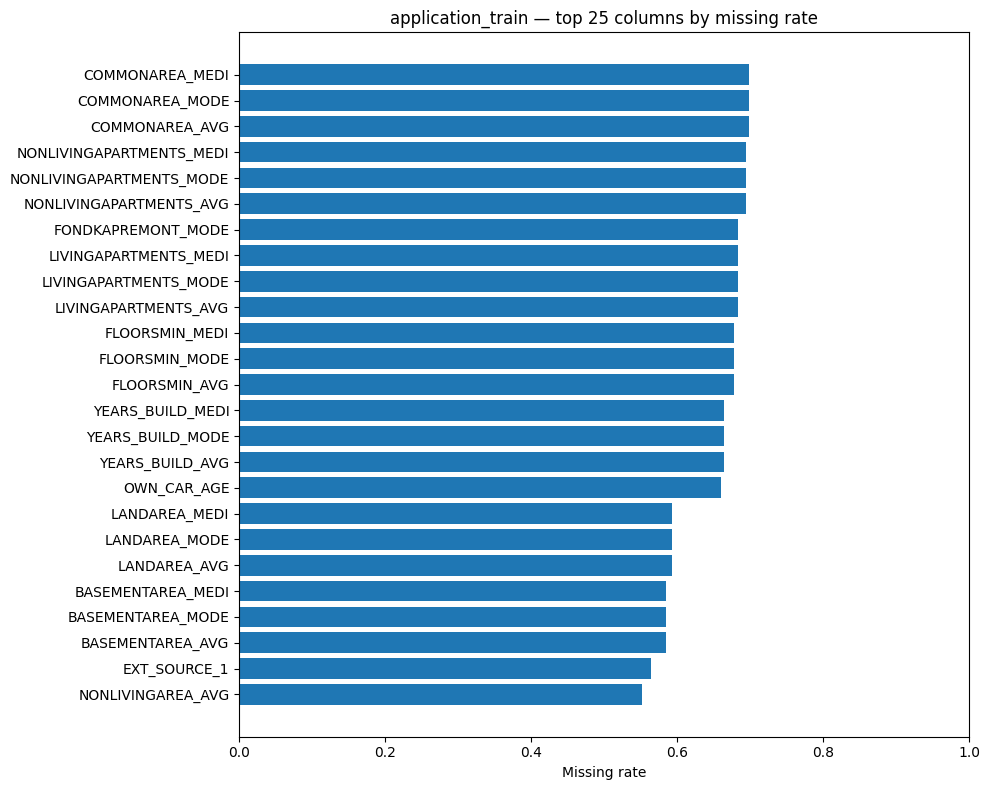

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = top_missing.sort("missing_rate")
ax.barh(plot_df["column"].to_list(), plot_df["missing_rate"].to_list())
ax.set_xlabel("Missing rate")
ax.set_title("application_train — top 25 columns by missing rate")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [11]:
# Important credit-score features: EXT_SOURCE_1/2/3
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
app_train.select(
    [
        pl.col(c).null_count().alias(f"{c}_nulls")
        for c in ext_cols
    ]
    + [
        (pl.col(c).null_count() / pl.len()).alias(f"{c}_missing_rate")
        for c in ext_cols
    ]
)

EXT_SOURCE_1_nulls,EXT_SOURCE_2_nulls,EXT_SOURCE_3_nulls,EXT_SOURCE_1_missing_rate,EXT_SOURCE_2_missing_rate,EXT_SOURCE_3_missing_rate
u32,u32,u32,f64,f64,f64
173378,660,60965,0.563811,0.002146,0.198253


## 4. Missing-value handling strategy

Rules applied below on `application_train` (same logic will be reused in `src/features/build_features.py`):

| Pattern | Action |
|---------|--------|
| **High missing (≥70%)** building/apartment aggregate columns (`COMMONAREA_*`, `LIVINGAPARTMENTS_*`, etc.) | Drop column — sparse and redundant with `_AVG` / `_MODE` / `_MEDI` families |
| **Categorical** (`NAME_*`, `OCCUPATION_TYPE`, `ORGANIZATION_TYPE`, …) | Fill with `"Missing"` |
| **Numeric** (amounts, counts, ratings) | Fill with **median** (robust to skew) |
| **Days-based** (`DAYS_*`) | Fill with **median**; keep sign semantics (negative = days before application) |
| **OWN_CAR_AGE** | Fill with `0` when `FLAG_OWN_CAR == N` (no car) |
| **EXT_SOURCE_1/2/3** | Fill with **median** + add `MISSING_EXT_SOURCE_*` indicator flags |

Relational tables (`bureau`, `previous_application`, …) are **not** imputed here; aggregations in the feature pipeline will handle their missing values per `SK_ID_CURR`.

In [12]:
DROP_HIGH_MISSING_PREFIXES = (
    "COMMONAREA_",
    "NONLIVINGAPARTMENTS_",
    "NONLIVINGAREA_",
    "FONDKAPREMONT_MODE",
    "LIVINGAPARTMENTS_",
)

CATEGORICAL_PREFIXES = ("NAME_", "OCCUPATION_TYPE", "ORGANIZATION_TYPE", "WEEKDAY_")
CATEGORICAL_EXACT = {
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "HOUSETYPE_MODE",
    "WALLSMATERIAL_MODE",
    "EMERGENCYSTATE_MODE",
}


def is_categorical(col: str, dtype: pl.DataType) -> bool:
    if dtype == pl.Utf8:
        return True
    if col in CATEGORICAL_EXACT:
        return True
    return any(col.startswith(p) for p in CATEGORICAL_PREFIXES)


def should_drop_column(col: str, missing_rate: float) -> bool:
    if missing_rate >= 0.70 and any(col.startswith(p) for p in DROP_HIGH_MISSING_PREFIXES):
        return True
    return False


def handle_missing_application(df: pl.DataFrame) -> pl.DataFrame:
    """Impute/drop missing values on the application table."""

    miss = missing_summary(df, "application_train.csv")
    miss_map = dict(zip(miss["column"].to_list(), miss["missing_rate"].to_list()))

    drop_cols = [
        c for c in df.columns
        if should_drop_column(c, miss_map.get(c, 0.0))
    ]

    out = df.drop(drop_cols) if drop_cols else df

    if "OWN_CAR_AGE" in out.columns and "FLAG_OWN_CAR" in out.columns:
        out = out.with_columns(
            pl.when(pl.col("FLAG_OWN_CAR") == "N")
            .then(0.0)
            .otherwise(pl.col("OWN_CAR_AGE"))
            .alias("OWN_CAR_AGE")
        )

    ext_cols = [c for c in out.columns if c.startswith("EXT_SOURCE")]

    ext_exprs = []
    for col in ext_cols:
        median_val = out[col].median()

        ext_exprs.append(
            pl.col(col)
            .is_null()
            .cast(pl.Int8)
            .alias(f"MISSING_{col}")
        )

        ext_exprs.append(
            pl.col(col)
            .fill_null(median_val)
            .alias(col)
        )

    general_exprs = []

    for col in out.columns:
        if col in ("SK_ID_CURR", "TARGET"):
            continue

        if col.startswith("EXT_SOURCE"):
            continue

        dtype = out.schema[col]

        if out[col].null_count() == 0:
            continue

        if is_categorical(col, dtype):
            general_exprs.append(
                pl.col(col).fill_null("Missing").alias(col)
            )

        elif dtype.is_numeric():
            median_val = out[col].median()
            general_exprs.append(
                pl.col(col).fill_null(median_val).alias(col)
            )

        else:
            general_exprs.append(
                pl.col(col).fill_null("Missing").alias(col)
            )

    all_exprs = ext_exprs + general_exprs

    if all_exprs:
        out = out.with_columns(all_exprs)

    return out

In [13]:
app_clean = handle_missing_application(app_train)

before_nulls = app_train.null_count().sum_horizontal()[0]
after_nulls = app_clean.null_count().sum_horizontal()[0]

print(f"Columns before: {app_train.width} → after: {app_clean.width}")
print(f"Null cells before: {before_nulls:,} → after: {after_nulls:,}")
assert after_nulls == 0, "Residual nulls remain after cleaning"

app_clean.head(3)

Columns before: 122 → after: 125
Null cells before: 9,152,465 → after: 0


SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,…,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,MISSING_EXT_SOURCE_1,MISSING_EXT_SOURCE_2,MISSING_EXT_SOURCE_3
i64,i64,str,str,str,str,i64,f64,f64,f64,f64,str,str,str,str,str,f64,i64,i64,f64,i64,f64,i64,i64,i64,i64,i64,i64,str,f64,i64,i64,str,i64,i64,i64,i64,…,f64,str,str,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i8,i8,i8
100002,1,"""Cash loans""","""M""","""N""","""Y""",0,202500.0,406597.5,24700.5,351000.0,"""Unaccompanied""","""Working""","""Secondary / secondary special""","""Single / not married""","""House / apartment""",0.018801,-9461,-637,-3648.0,-2120,0.0,1,1,0,1,1,0,"""Laborers""",1.0,2,2,"""WEDNESDAY""",10,0,0,0,…,0.0149,"""Stone, brick""","""No""",2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
100003,0,"""Cash loans""","""F""","""N""","""N""",0,270000.0,1293502.5,35698.5,1.1295e6,"""Family""","""State servant""","""Higher education""","""Married""","""House / apartment""",0.003541,-16765,-1188,-1186.0,-291,0.0,1,1,0,1,1,0,"""Core staff""",2.0,1,1,"""MONDAY""",11,0,0,0,…,0.0714,"""Block""","""No""",1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1
100004,0,"""Revolving loans""","""M""","""Y""","""Y""",0,67500.0,135000.0,6750.0,135000.0,"""Unaccompanied""","""Working""","""Secondary / secondary special""","""Single / not married""","""House / apartment""",0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,"""Laborers""",1.0,2,2,"""MONDAY""",9,0,0,0,…,0.0688,"""Missing""","""Missing""",0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0


In [14]:
app_clean.write_parquet(
    PROCESSED_DIR / "application_train_cleaned.parquet",
    compression="snappy",
)
print(f"Saved → {PROCESSED_DIR / 'application_train_cleaned.parquet'}")

Saved → D:\modern-data-science-tech-stack\projects\Credit Risk Intelligence Platform\data\processed\application_train_cleaned.parquet


## 5. Summary & next steps

- **Class imbalance:** default rate ~8% — use appropriate metrics (AUC, Gini, KS) and stratified/temporal splits (see `Cursor.md`).
- **Sparse building features:** many `*_AVG/_MODE/_MEDI` columns are >65% missing; dropped when ≥70% missing.
- **Bureau / previous application:** high missing on optional fields (`AMT_ANNUITY`, rate columns) — handle during aggregation in `02_feature_exploration.ipynb` / `src/features/build_features.py`.
- **Next:** join relational tables on `SK_ID_CURR`, build aggregated features, and register definitions in `src/features/feature_registry.py`.